In [ ]:
!pip install kagglehub -q
print("kagglehub установлен")

In [17]:

import os
import kagglehub
import shutil

print("Скачивание датасета Stanford Dogs...")
path = kagglehub.dataset_download("jessicali9530/stanford-dogs-dataset")
print(f"Датасет скачан в: {path}")

# Посмотрим структуру скачанных файлов
print("\nСодержимое скачанной папки:")
for item in os.listdir(path):
    item_path = os.path.join(path, item)
    if os.path.isdir(item_path):
        print(f"  📁 {item}")
        # Показываем вложенные папки
        for subitem in os.listdir(item_path):
            print(f"      📄 {subitem}")
    else:
        print(f"  📄 {item}")

# Ищем папку с изображениями
images_found = None
for root, dirs, files in os.walk(path):
    if "Images" in dirs:
        images_found = os.path.join(root, "Images")
        break
    # Ищем jpg файлы
    for file in files:
        if file.endswith('.jpg'):
            images_found = root
            break
    if images_found:
        break

if images_found:
    print(f"\n✅ Папка с изображениями найдена: {images_found}")
else:
    print("\n❌ Папка с изображениями не найдена!")

# Создаем рабочую структуру
DATA_PATH = "/content/stanford_dogs"
os.makedirs(DATA_PATH, exist_ok=True)

if images_found:
    target_images = os.path.join(DATA_PATH, "images", "Images")
    os.makedirs(os.path.dirname(target_images), exist_ok=True)
    if not os.path.exists(target_images):
        shutil.copytree(images_found, target_images)
        print(f"✅ Изображения скопированы в {target_images}")

Скачивание датасета Stanford Dogs...
Using Colab cache for faster access to the 'stanford-dogs-dataset' dataset.
Датасет скачан в: /kaggle/input/stanford-dogs-dataset

Содержимое скачанной папки:
  📁 annotations
      📄 Annotation
  📁 images
      📄 Images

✅ Папка с изображениями найдена: /kaggle/input/stanford-dogs-dataset/images/Images


In [ ]:
# ==================== ЯЧЕЙКА 2: Проверка структуры ====================
# Проверяем, что у нас получилось
test_path = "/content/stanford_dogs/images/Images"

if os.path.exists(test_path):
    print(f"✅ Папка существует: {test_path}")
    classes = [d for d in os.listdir(test_path) if os.path.isdir(os.path.join(test_path, d))]
    print(f"Количество классов (пород): {len(classes)}")

    if classes:
        first_class = classes[0]
        first_class_path = os.path.join(test_path, first_class)
        images = [f for f in os.listdir(first_class_path) if f.endswith('.jpg')]
        print(f"Первый класс: {first_class}")
        print(f"Количество изображений в первом классе: {len(images)}")
        if images:
            print(f"Пример изображения: {images[0]}")
else:
    print(f"❌ Папка не найдена: {test_path}")
    # Альтернативный поиск
    alt_path = "/content/stanford_dogs/Images"
    if os.path.exists(alt_path):
        print(f"✅ Найдено альтернативное расположение: {alt_path}")
        # Пересоздаем структуру
        os.makedirs("/content/stanford_dogs/images", exist_ok=True)
        if not os.path.exists("/content/stanford_dogs/images/Images"):
            shutil.move(alt_path, "/content/stanford_dogs/images/Images")
            print("✅ Структура исправлена")

In [ ]:
# ==================== ЯЧЕЙКА 3: Импорт библиотек ====================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import Adam, RAdam
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import precision_recall_fscore_support
import numpy as np
import matplotlib.pyplot as plt
from torchvision.models import resnext50_32x4d, ResNeXt50_32X4D_Weights
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

In [ ]:
# ==================== ЯЧЕЙКА 4: Упрощенный класс датасета ====================
class StanfordDogsDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform

        # Пробуем разные возможные пути
        possible_paths = [
            os.path.join(root_dir, "images", "Images"),
            os.path.join(root_dir, "Images"),
            root_dir
        ]

        self.images_dir = None
        for path in possible_paths:
            if os.path.exists(path) and os.path.isdir(path):
                # Проверяем, есть ли внутри папки с классами
                subdirs = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]
                if subdirs:
                    self.images_dir = path
                    break

        if self.images_dir is None:
            raise FileNotFoundError(f"Не найдена папка с изображениями в {root_dir}")

        # Получаем список классов
        self.classes = sorted([d for d in os.listdir(self.images_dir)
                              if os.path.isdir(os.path.join(self.images_dir, d))])
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}

        # Собираем все изображения
        self.image_paths = []
        self.labels = []

        for class_name in self.classes:
            class_dir = os.path.join(self.images_dir, class_name)
            class_idx = self.class_to_idx[class_name]

            for img_file in os.listdir(class_dir):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.image_paths.append(os.path.join(class_dir, img_file))
                    self.labels.append(class_idx)

        print(f"✅ Загружено {len(self.image_paths)} изображений")
        print(f"✅ Количество классов: {len(self.classes)}")
        print(f"✅ Пример класса: {self.classes[0]}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

In [21]:
# ==================== ЯЧЕЙКА 5: Настройки ====================
IMAGE_SIZE = 224
BATCH_SIZE = 64
NUM_EPOCHS_FINETUNE = 5
NUM_EPOCHS_SCRATCH = 10
NUM_CLASSES = 120

# Аугментации
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Настройки загружены")

Настройки загружены


In [22]:
# ==================== ЯЧЕЙКА 6: Загрузка данных ====================
DATA_PATH = "/content/stanford_dogs"

print("Загрузка обучающего датасета с аугментациями...")
full_dataset = StanfordDogsDataset(root_dir=DATA_PATH, transform=train_transform)

# Разделение
total_size = len(full_dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

# Перемешивание
indices = list(range(total_size))
np.random.seed(42)
np.random.shuffle(indices)

train_indices = indices[:train_size]
val_indices = indices[train_size:train_size + val_size]
test_indices = indices[train_size + val_size:]

# Создаем датасеты
train_dataset = torch.utils.data.Subset(full_dataset, train_indices)

# Для валидации и теста без аугментаций
full_dataset_val = StanfordDogsDataset(root_dir=DATA_PATH, transform=val_transform)
val_dataset = torch.utils.data.Subset(full_dataset_val, val_indices)
test_dataset = torch.utils.data.Subset(full_dataset_val, test_indices)

# DataLoader'ы
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"\nРазделение данных:")
print(f"  Train: {len(train_dataset)}")
print(f"  Val: {len(val_dataset)}")
print(f"  Test: {len(test_dataset)}")

Загрузка обучающего датасета с аугментациями...
✅ Загружено 20580 изображений
✅ Количество классов: 120
✅ Пример класса: n02085620-Chihuahua
✅ Загружено 20580 изображений
✅ Количество классов: 120
✅ Пример класса: n02085620-Chihuahua

Разделение данных:
  Train: 14405
  Val: 3087
  Test: 3088


In [23]:
# ==================== ЯЧЕЙКА 7: Быстрый тест датасета ====================
# Проверяем, что датасет работает
print("Тест загрузки одного батча...")
for images, labels in train_loader:
    print(f"Shape изображений: {images.shape}")
    print(f"Shape меток: {labels.shape}")
    print(f"Пример метки: {labels[0].item()}")
    print(f"Диапазон значений пикселей: [{images.min():.2f}, {images.max():.2f}]")
    break

print("\n✅ Датасет работает корректно!")

Тест загрузки одного батча...
Shape изображений: torch.Size([64, 3, 224, 224])
Shape меток: torch.Size([64])
Пример метки: 52
Диапазон значений пикселей: [-2.12, 2.64]

✅ Датасет работает корректно!


In [24]:
# ==================== ЯЧЕЙКА 8: Функции обучения ====================
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0
    all_preds, all_labels = [], []

    for images, labels in tqdm(loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro', zero_division=0)

    return epoch_loss, precision, recall, f1

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro', zero_division=0)

    return epoch_loss, precision, recall, f1

In [25]:
# ==================== ЯЧЕЙКА 9: Создание модели ====================
def create_model(num_classes, pretrained=True):
    if pretrained:
        print("Загрузка предобученной модели ResNeXt...")
        model = resnext50_32x4d(weights=ResNeXt50_32X4D_Weights.IMAGENET1K_V1)
    else:
        print("Создание модели с нуля...")
        model = resnext50_32x4d(weights=None)

    # Заменяем последний слой
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    return model

# Тест создания модели
test_model = create_model(120, pretrained=True)
print(f"✅ Модель создана: {test_model.__class__.__name__}")
print(f"Количество параметров: {sum(p.numel() for p in test_model.parameters()) / 1e6:.1f}M")

Загрузка предобученной модели ResNeXt...
✅ Модель создана: ResNet
Количество параметров: 23.2M


In [ ]:
# ==================== ЯЧЕЙКА 10: Эксперимент 1 (Adam Fine-tune) ====================
print("\n" + "="*60)
print("ЭКСПЕРИМЕНТ 1: Fine-tuning с Adam")
print("="*60)

model1 = create_model(NUM_CLASSES, pretrained=True).to(device)
criterion = nn.CrossEntropyLoss()
optimizer1 = Adam(model1.parameters(), lr=1e-4)

best_f1 = 0
for epoch in range(NUM_EPOCHS_FINETUNE):
    train_loss, train_prec, train_rec, train_f1 = train_epoch(model1, train_loader, criterion, optimizer1, device)
    val_loss, val_prec, val_rec, val_f1 = validate(model1, val_loader, criterion, device)

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model1.state_dict(), 'best_model_adam.pth')

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS_FINETUNE}")
    print(f"  Train Loss: {train_loss:.4f}, F1: {train_f1:.4f}")
    print(f"  Val Loss: {val_loss:.4f}, F1: {val_f1:.4f}, Prec: {val_prec:.4f}, Rec: {val_rec:.4f}")
    print(f"  Best F1: {best_f1:.4f}")


ЭКСПЕРИМЕНТ 1: Fine-tuning с Adam
Загрузка предобученной модели ResNeXt...


Validation: 100%|██████████| 49/49 [00:17<00:00,  2.84it/s]



Epoch 1/5
  Train Loss: 2.0556, F1: 0.5477
  Val Loss: 0.8583, F1: 0.7422, Prec: 0.7701, Rec: 0.7494
  Best F1: 0.7422


Validation: 100%|██████████| 49/49 [00:16<00:00,  2.93it/s]



Epoch 2/5
  Train Loss: 0.7778, F1: 0.7821
  Val Loss: 0.7868, F1: 0.7597, Prec: 0.7819, Rec: 0.7641
  Best F1: 0.7597


...


Epoch 3/5
  Train Loss: 0.5035, F1: 0.8527
  Val Loss: 0.7587, F1: 0.7667, Prec: 0.7880, Rec: 0.7745
  Best F1: 0.7667


Validation: 100%|██████████| 49/49 [00:19<00:00,  2.47it/s]



Epoch 4/5
  Train Loss: 0.3329, F1: 0.9039
  Val Loss: 0.7690, F1: 0.7638, Prec: 0.7897, Rec: 0.7641
  Best F1: 0.7667


Validation: 100%|██████████| 49/49 [00:18<00:00,  2.61it/s]



Epoch 5/5
  Train Loss: 0.2274, F1: 0.9360
  Val Loss: 0.7241, F1: 0.7781, Prec: 0.7906, Rec: 0.7813
  Best F1: 0.7781


In [12]:
# ==================== ЯЧЕЙКА 11: Эксперимент 2 (RAdam Fine-tune) ====================
print("\n" + "="*60)
print("ЭКСПЕРИМЕНТ 2: Fine-tuning с RAdam")
print("="*60)

model2 = create_model(NUM_CLASSES, pretrained=True).to(device)
optimizer2 = RAdam(model2.parameters(), lr=1e-4)

best_f1 = 0
for epoch in range(NUM_EPOCHS_FINETUNE):
    train_loss, train_prec, train_rec, train_f1 = train_epoch(model2, train_loader, criterion, optimizer2, device)
    val_loss, val_prec, val_rec, val_f1 = validate(model2, val_loader, criterion, device)

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model2.state_dict(), 'best_model_radam.pth')

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS_FINETUNE}")
    print(f"  Train Loss: {train_loss:.4f}, F1: {train_f1:.4f}")
    print(f"  Val Loss: {val_loss:.4f}, F1: {val_f1:.4f}, Prec: {val_prec:.4f}, Rec: {val_rec:.4f}")
    print(f"  Best F1: {best_f1:.4f}")


ЭКСПЕРИМЕНТ 2: Fine-tuning с RAdam
Загрузка предобученной модели ResNeXt...


Validation: 100%|██████████| 49/49 [00:18<00:00,  2.66it/s]



Epoch 1/5
  Train Loss: 3.8468, F1: 0.2694
  Val Loss: 1.9408, F1: 0.6292, Prec: 0.7409, Rec: 0.6557
  Best F1: 0.6292


Validation: 100%|██████████| 49/49 [00:18<00:00,  2.68it/s]



Epoch 2/5
  Train Loss: 1.5833, F1: 0.6683
  Val Loss: 0.8765, F1: 0.7843, Prec: 0.7994, Rec: 0.7930
  Best F1: 0.7843


...


Epoch 3/5
  Train Loss: 0.8441, F1: 0.7911
  Val Loss: 0.7151, F1: 0.7830, Prec: 0.7948, Rec: 0.7884
  Best F1: 0.7843


Validation: 100%|██████████| 49/49 [00:18<00:00,  2.71it/s]



Epoch 4/5
  Train Loss: 0.5508, F1: 0.8542
  Val Loss: 0.6494, F1: 0.8047, Prec: 0.8184, Rec: 0.8092
  Best F1: 0.8047


Validation: 100%|██████████| 49/49 [00:17<00:00,  2.81it/s]



Epoch 5/5
  Train Loss: 0.3730, F1: 0.8992
  Val Loss: 0.6288, F1: 0.8082, Prec: 0.8198, Rec: 0.8121
  Best F1: 0.8082


In [13]:
# ==================== ЯЧЕЙКА 12: Эксперимент 3 (Обучение с нуля) ====================
print("\n" + "="*60)
print("ЭКСПЕРИМЕНТ 3: Обучение с нуля + Adam")
print("="*60)

model3 = create_model(NUM_CLASSES, pretrained=False).to(device)

# Инициализация весов
def init_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

model3.apply(init_weights)
optimizer3 = Adam(model3.parameters(), lr=1e-3)

best_f1 = 0
for epoch in range(NUM_EPOCHS_SCRATCH):
    train_loss, train_prec, train_rec, train_f1 = train_epoch(model3, train_loader, criterion, optimizer3, device)
    val_loss, val_prec, val_rec, val_f1 = validate(model3, val_loader, criterion, device)

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model3.state_dict(), 'best_model_scratch.pth')

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS_SCRATCH}")
    print(f"  Train Loss: {train_loss:.4f}, F1: {train_f1:.4f}")
    print(f"  Val Loss: {val_loss:.4f}, F1: {val_f1:.4f}, Prec: {val_prec:.4f}, Rec: {val_rec:.4f}")
    print(f"  Best F1: {best_f1:.4f}")


ЭКСПЕРИМЕНТ 3: Обучение с нуля + Adam
Создание модели с нуля...


Validation: 100%|██████████| 49/49 [00:18<00:00,  2.70it/s]



Epoch 1/10
  Train Loss: 5.7560, F1: 0.0157
  Val Loss: 4.7075, F1: 0.0107, Prec: 0.0171, Rec: 0.0243
  Best F1: 0.0107


Validation: 100%|██████████| 49/49 [00:17<00:00,  2.83it/s]



Epoch 2/10
  Train Loss: 4.6772, F1: 0.0269
  Val Loss: 8.9704, F1: 0.0199, Prec: 0.0238, Rec: 0.0402
  Best F1: 0.0199


...


Epoch 8/10
  Train Loss: 3.8873, F1: 0.0991
  Val Loss: 4.0615, F1: 0.0735, Prec: 0.1191, Rec: 0.0977
  Best F1: 0.0752


Validation: 100%|██████████| 49/49 [00:17<00:00,  2.85it/s]



Epoch 9/10
  Train Loss: 3.7701, F1: 0.1138
  Val Loss: 8.7637, F1: 0.0566, Prec: 0.1137, Rec: 0.0712
  Best F1: 0.0752


Validation: 100%|██████████| 49/49 [00:16<00:00,  2.91it/s]



Epoch 10/10
  Train Loss: 3.5898, F1: 0.1446
  Val Loss: 4.3527, F1: 0.0922, Prec: 0.1427, Rec: 0.1073
  Best F1: 0.0922


In [ ]:
# ==================== ЯЧЕЙКА 13: Тестирование на тестовой выборке ====================
def test_model(model, loader, device, name):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc=f"Testing {name}"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro')
    return precision, recall, f1

# Загружаем лучшие модели
model1.load_state_dict(torch.load('best_model_adam.pth'))
model2.load_state_dict(torch.load('best_model_radam.pth'))
model3.load_state_dict(torch.load('best_model_scratch.pth'))

# Тестируем
results = {}
for name, model in [("Adam Fine-tune", model1), ("RAdam Fine-tune", model2), ("Scratch Adam", model3)]:
    prec, rec, f1 = test_model(model, test_loader, device, name)
    results[name] = {"Precision": prec, "Recall": rec, "F1": f1}
    print(f"\n{name}:")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall: {rec:.4f}")
    print(f"  F1-score: {f1:.4f}")

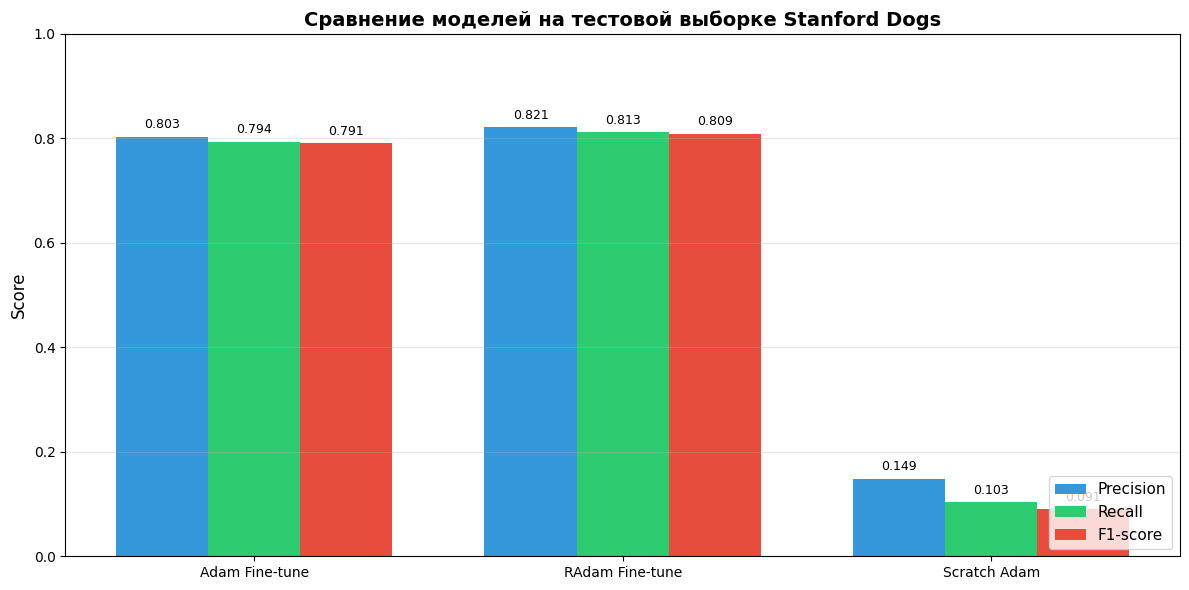


✅ Все эксперименты завершены успешно!
📊 График сохранен как 'comparison_results.png'


In [15]:
# ==================== ЯЧЕЙКА 14: Визуализация ====================
names = list(results.keys())
precisions = [results[n]["Precision"] for n in names]
recalls = [results[n]["Recall"] for n in names]
f1_scores = [results[n]["F1"] for n in names]

x = np.arange(len(names))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width, precisions, width, label='Precision', color='#3498db')
bars2 = ax.bar(x, recalls, width, label='Recall', color='#2ecc71')
bars3 = ax.bar(x + width, f1_scores, width, label='F1-score', color='#e74c3c')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Сравнение моделей на тестовой выборке Stanford Dogs', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=10)
ax.legend(loc='lower right', fontsize=11)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('comparison_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Все эксперименты завершены успешно!")
print("📊 График сохранен как 'comparison_results.png'")